# Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cek Dataset

# EDA

### Load & Sanitize Data

### Augmentasi Data

In [27]:
df = pd.read_csv('/content/exercise_balanced_800.csv')
df

,#,Major_Heading,Activity_Code,MET_Value,Intensity_Level,Goal_Tag,Activity_Description,Cal_60kg_per_30min,Cal_70kg_per_30min,Cal_80kg_per_30min
0,1,Bicycling,1003,14.0,Vigorous,Weight Loss,"Bicycling, mountain, uphill, vigorous",420,490.0,560
1,2,Bicycling,1004,16.0,Vigorous,Weight Loss,"Bicycling, mountain, competitive racing",480,560.0,640
2,3,Bicycling,1008,8.5,Vigorous,Weight Loss,"Bicycling, BMX",255,297.5,340
3,4,Bicycling,1009,8.5,Vigorous,Weight Loss,"Bicycling, mountain, general",255,297.5,340
4,5,Bicycling,1010,4.0,Moderate,Weight Loss,"Bicycling, <10 mph, leisure, to work or for pl...",120,140.0,160
...,...,...,...,...,...,...,...,...,...,...
1570,1571,Miscellaneous,20770,1.5,Sedentary,Health Maintenance,"Reading while sitting, variation 394",45,52.0,60
1571,1572,Miscellaneous,20771,1.1,Sedentary,Health Maintenance,"Lying down, awake, variation 395",33,38.0,44
1572,1573,Miscellaneous,20772,1.4,Sedentary,Health Maintenance,"Sitting quietly, variation 396",42,49.0,56
1573,1574,Miscellaneous,20773,1.5,Sedentary,Health Maintenance,"Reading while sitting, variation 397",45,52.0,60


In [29]:
import pandas as pd
import random

# Definisi Struktur Kategori dan Aktivitas Spesifik dari User
activity_map = {
    'Sports': ['Football', 'Badminton', 'Tennis', 'Padel', 'Basketball', 'Volleyball'],
    'Running': ['Sprint', 'Marathon', 'Jogging'],
    'Walking': ['Racewalking', 'Interval', 'Hiking'],
    'Water Activities': ['Freestyle', 'Breaststroke', 'Backstroke', 'Butterfly Stroke'],
    'Conditioning Exercise': ['Skipping', 'Squat', 'Box Jumps', 'Push-up', 'Pull-up', 'Plank', 'Kardio'],
    'Resistance Training': ['Dumbbell Shoulder Press', 'Deadlift', 'Bench Press', 'Bicep Curls', 'Tricep Extension', 'Standing Row', 'Leg Press', 'Cable Row', 'Chest Press']
}

# Goal Tags based on Category
goal_map = {
    'Sports': 'Cardio & Agility',
    'Running': 'Cardio & Endurance',
    'Walking': 'Health Maintenance',
    'Water Activities': 'Full Body Cardio',
    'Conditioning Exercise': 'Core & Stamina',
    'Resistance Training': 'Muscle Gain'
}

data_rows = []
start_id = 1
activity_code = 10000

# Fungsi untuk generate deskripsi yang masuk akal berdasarkan Intensitas
def generate_description(activity, intensity):
    if intensity == 'Sedentary':
        descs = [f"Sitting/resting during {activity} session", f"Listening to coach before {activity}", f"Lying down after {activity} workout", f"Watching {activity} match while sitting"]
    elif intensity == 'Light':
        descs = [f"Light warm-up for {activity}", f"Slow and relaxed {activity} practice", f"Stretching before {activity}", f"Low-effort {activity} movement"]
    elif intensity == 'Moderate':
        descs = [f"Casual/Social {activity} session", f"Moderate-paced {activity} workout", f"{activity} with steady effort", f"Recreational {activity}"]
    else: # Vigorous
        descs = [f"Competitive high-intensity {activity}", f"Maximum effort {activity}", f"Heavy and fast {activity} training", f"Intense {activity} competition"]
    return random.choice(descs)

# Target: 3000 total (4 kelas = masing-masing 750)
target_per_class = 750

intensities = {
    'Sedentary': {'count': 0, 'range': (1.0, 1.4)},
    'Light': {'count': 0, 'range': (1.5, 2.9)},
    'Moderate': {'count': 0, 'range': (3.0, 5.9)},
    'Vigorous': {'count': 0, 'range': (6.0, 16.0)}
}

# Generate Data
for intensity, config in intensities.items():
    while config['count'] < target_per_class:
        # Pick random category and activity
        category = random.choice(list(activity_map.keys()))
        activity = random.choice(activity_map[category])

        # Generate MET based on realistic intensity boundaries
        met = round(random.uniform(config['range'][0], config['range'][1]), 1)

        # Penyesuaian khusus dengan deskripsi
        desc = generate_description(activity, intensity)

        cal_60 = int(met * 60 * 0.5)
        cal_70 = int(met * 70 * 0.5)
        cal_80 = int(met * 80 * 0.5)

        data_rows.append({
            '#': start_id,
            'Category': category,
            'Specific_Activity': activity,
            'Activity_Code': activity_code,
            'MET_Value': met,
            'Intensity_Level': intensity,
            'Goal_Tag': goal_map[category],
            'Activity_Description': desc,
            'Cal_60kg_per_30min': cal_60,
            'Cal_70kg_per_30min': cal_70,
            'Cal_80kg_per_30min': cal_80
        })

        start_id += 1
        activity_code += 1
        config['count'] += 1

# Shuffle data biar acak
random.shuffle(data_rows)

# Update ID biar urut lagi setelah di-shuffle
for idx, row in enumerate(data_rows):
    row['#'] = idx + 1

df_final = pd.DataFrame(data_rows)
output_file = 'dataset_fitstreak_3000.csv'
df_final.to_csv(output_file, index=False)

print(f"Dataset berhasil dibuat: {output_file}")
print("Total Baris:", len(df_final))

Dataset berhasil dibuat: dataset_fitstreak_3000.csv
Total Baris: 3000


In [57]:
df = pd.read_csv('/content/dataset_fitstreak_3000.csv')
df

,#,Category,Specific_Activity,Activity_Code,MET_Value,Intensity_Level,Goal_Tag,Activity_Description,Cal_60kg_per_30min,Cal_70kg_per_30min,Cal_80kg_per_30min
0,1,Water Activities,Freestyle,10452,1.3,Sedentary,Full Body Cardio,Listening to coach before Freestyle,39,45,52
1,2,Resistance Training,Bench Press,10461,1.1,Sedentary,Muscle Gain,Listening to coach before Bench Press,33,38,44
2,3,Conditioning Exercise,Push-up,12859,11.9,Vigorous,Core & Stamina,Competitive high-intensity Push-up,357,416,476
3,4,Water Activities,Breaststroke,10739,1.3,Sedentary,Full Body Cardio,Sitting/resting during Breaststroke session,39,45,52
4,5,Conditioning Exercise,Box Jumps,12057,3.4,Moderate,Core & Stamina,Box Jumps with steady effort,102,119,136
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Sports,Padel,10742,1.2,Sedentary,Cardio & Agility,Sitting/resting during Padel session,36,42,48
2996,2997,Resistance Training,Cable Row,11134,2.1,Light,Muscle Gain,Stretching before Cable Row,63,73,84
2997,2998,Water Activities,Freestyle,12140,3.3,Moderate,Full Body Cardio,Casual/Social Freestyle session,99,115,132
2998,2999,Water Activities,Butterfly Stroke,10990,2.0,Light,Full Body Cardio,Slow and relaxed Butterfly Stroke practice,60,70,80


In [56]:
# Hapus beberapa aktivitas sekaligus
hapus = ['Canoeing', 'Rowing', 'Kayaking']

pattern = '|'.join(hapus)
df = df[~df['Activity_Description'].str.contains(pattern, case=False, na=False)]

print(f"Sisa data: {len(df)} baris")

Sisa data: 3000 baris


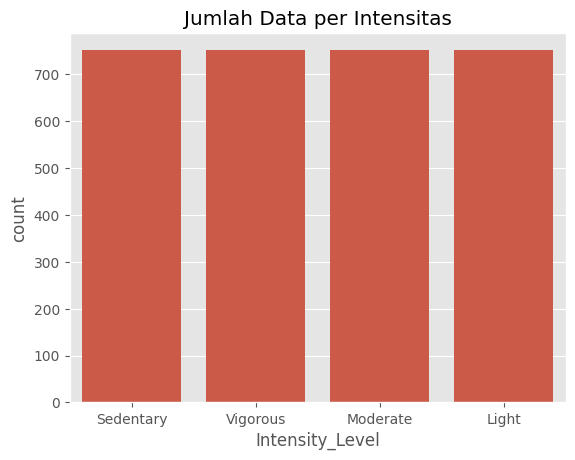

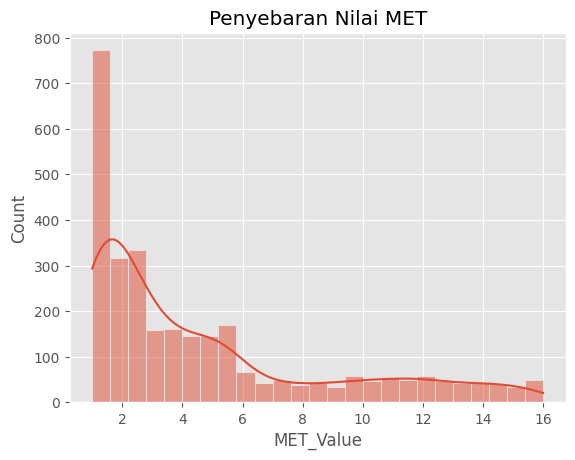

Intensity_Level
Sedentary    750
Vigorous     750
Moderate     750
Light        750
Name: count, dtype: int64
count    3000.000000
mean        4.723933
std         4.092393
min         1.000000
25%         1.475000
50%         2.950000
75%         5.925000
max        16.000000
Name: MET_Value, dtype: float64


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualisasi Kategorikal (Intensity)
sns.countplot(data=df, x='Intensity_Level')
plt.title('Jumlah Data per Intensitas')
plt.show()

# 2. Visualisasi Numerik (MET)
sns.histplot(df['MET_Value'], kde=True)
plt.title('Penyebaran Nilai MET')
plt.show()

# 3. Statistik Deskriptif
print(df['Intensity_Level'].value_counts())
print(df['MET_Value'].describe())

In [32]:
# Cleaning (Hapus spasi di nama kolom)
df.columns = df.columns.str.strip()

In [33]:
# Missing values
df.isnull().sum()

,0
#,0
Category,0
Specific_Activity,0
Activity_Code,0
MET_Value,0
Intensity_Level,0
Goal_Tag,0
Activity_Description,0
Cal_60kg_per_30min,0
Cal_70kg_per_30min,0


In [34]:
# Statistik MET
df['MET_Value'].describe()

,MET_Value
count,3000.000000
mean,4.723933
std,4.092393
min,1.000000
25%,1.475000
50%,2.950000
75%,5.925000
max,16.000000


# Preprocessing

In [36]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le_category = LabelEncoder()
le_intensity = LabelEncoder()
le_goal = LabelEncoder()

# Encode kolom kategorikal
df['Category_Encoded'] = le_category.fit_transform(df['Category'])
df['Intensity_Encoded'] = le_intensity.fit_transform(df['Intensity_Level'])
df['Goal_Encoded']      = le_goal.fit_transform(df['Goal_Tag'])

# Simpan mapping untuk inference nanti
mapping_category  = dict(zip(le_category.classes_,  le_category.transform(le_category.classes_)))
mapping_intensity = dict(zip(le_intensity.classes_, le_intensity.transform(le_intensity.classes_)))
mapping_goal      = dict(zip(le_goal.classes_,      le_goal.transform(le_goal.classes_)))

print("Category  :", mapping_category)
print("Intensity :", mapping_intensity)
print("Goal      :", mapping_goal)

Category  : {'Conditioning Exercise': np.int64(0), 'Resistance Training': np.int64(1), 'Running': np.int64(2), 'Sports': np.int64(3), 'Walking': np.int64(4), 'Water Activities': np.int64(5)}
Intensity : {'Light': np.int64(0), 'Moderate': np.int64(1), 'Sedentary': np.int64(2), 'Vigorous': np.int64(3)}
Goal      : {'Cardio & Agility': np.int64(0), 'Cardio & Endurance': np.int64(1), 'Core & Stamina': np.int64(2), 'Full Body Cardio': np.int64(3), 'Health Maintenance': np.int64(4), 'Muscle Gain': np.int64(5)}


In [37]:
def ai_recommender(user_weight, user_bmi):
  # Logic
  if user_bmi >= 30:
    target = "Light"
  elif user_bmi >= 25:
    target = 'Moderate'
  else:
    target = 'Vigorous'

  candidates = df[df['Intensity_Level'] == target]
  recommendation = candidates.sample(1).iloc[0]

  duration_min = 30
  calories = recommendation['MET_Value'] * user_weight * (duration_min/60)

  return {
      "Activity": recommendation['Activity_Description'],
      "Intensity": recommendation['Intensity_Level'],
      "Calories_Burned": round(calories, 2),
      "MET": recommendation['MET_Value']
  }

print(ai_recommender(90, 31.1))

{'Activity': 'Low-effort Volleyball movement', 'Intensity': 'Light', 'Calories_Burned': np.float64(108.0), 'MET': np.float64(2.4)}


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   #                     3000 non-null   int64  
 1   Category              3000 non-null   object 
 2   Specific_Activity     3000 non-null   object 
 3   Activity_Code         3000 non-null   int64  
 4   MET_Value             3000 non-null   float64
 5   Intensity_Level       3000 non-null   object 
 6   Goal_Tag              3000 non-null   object 
 7   Activity_Description  3000 non-null   object 
 8   Cal_60kg_per_30min    3000 non-null   int64  
 9   Cal_70kg_per_30min    3000 non-null   int64  
 10  Cal_80kg_per_30min    3000 non-null   int64  
 11  Category_Encoded      3000 non-null   int64  
 12  Intensity_Encoded     3000 non-null   int64  
 13  Goal_Encoded          3000 non-null   int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 328.3+ KB


In [55]:
import numpy as np

# BMI range realistis berdasarkan intensitas latihan
bmi_range_map = {
    'Sedentary': (27.0, 40.0),   # cenderung orang dengan BMI tinggi
    'Light':     (25.0, 35.0),
    'Moderate':  (22.0, 30.0),
    'Vigorous':  (18.5, 25.0),
}

np.random.seed(42)
bmi_values    = []
streak_values = []

for _, row in df.iterrows():
    lo, hi = bmi_range_map.get(row['Intensity_Level'], (18.5, 35.0))
    bmi_values.append(round(np.random.uniform(lo, hi), 1))
    streak_values.append(np.random.randint(0, 12))  # minggu ke-0 s/d 11

df['User_BMI']         = bmi_values
df['Streak_Week']      = streak_values

print(df[['Intensity_Level','User_BMI','Streak_Week']].head(10))
print(df.shape)

  Intensity_Level  User_BMI  Streak_Week
0       Sedentary      31.9           10
1       Sedentary      37.1            4
2        Vigorous      19.5            2
3       Sedentary      28.3           10
4        Moderate      28.9            3
5        Vigorous      19.4            2
6       Sedentary      27.3            1
7        Moderate      27.8            5
8        Moderate      22.0           11
9           Light      26.8           11
(3000, 16)


# Model

### Random Forest

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [40]:
from sklearn.model_selection import train_test_split

# 5 fitur: MET + Category + Goal + BMI user + minggu streak
X = df[['MET_Value', 'Category_Encoded', 'Goal_Encoded', 'User_BMI', 'Streak_Week']]
y = df['Intensity_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("Kelas y       :", np.unique(y))

X_train shape : (2400, 5)
X_test shape  : (600, 5)
Kelas y       : [0 1 2 3]


Random Forest Accuracy: 100.00%


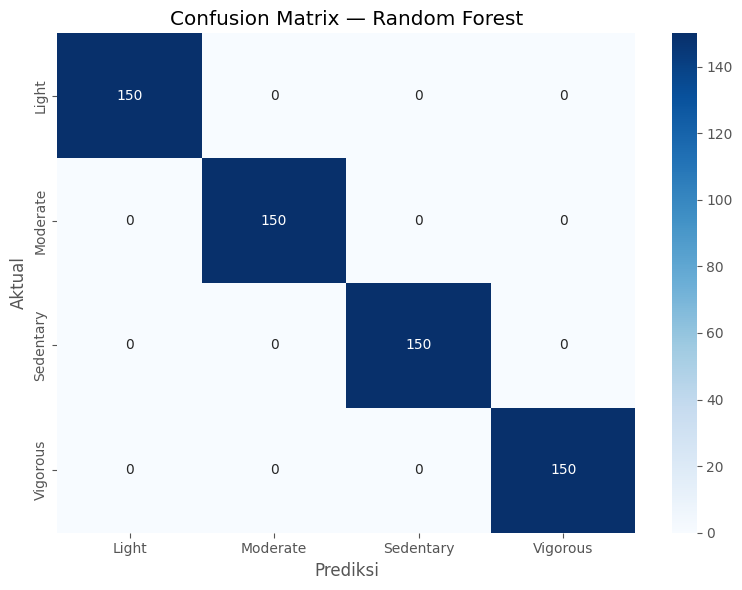

              precision    recall  f1-score   support

       Light       1.00      1.00      1.00       150
    Moderate       1.00      1.00      1.00       150
   Sedentary       1.00      1.00      1.00       150
    Vigorous       1.00      1.00      1.00       150

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



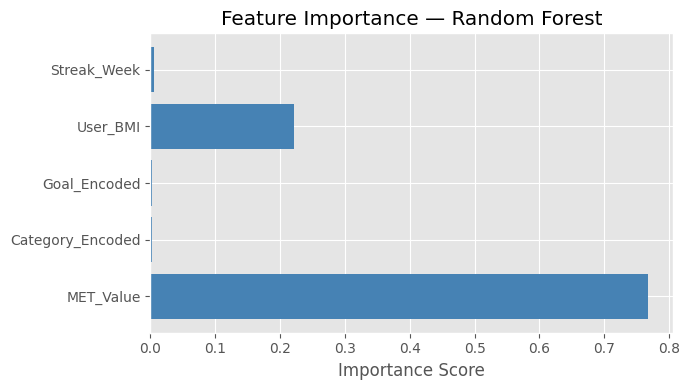

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_intensity.classes_,
            yticklabels=le_intensity.classes_)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=le_intensity.classes_))

# Feature Importance
feat_names = ['MET_Value', 'Category_Encoded', 'Goal_Encoded', 'User_BMI', 'Streak_Week']
importances = rf_model.feature_importances_
plt.figure(figsize=(7, 4))
plt.barh(feat_names, importances, color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Neural Network

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler

scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled  = scaler_nn.transform(X_test)

In [43]:
num_classes = len(le_intensity.classes_)

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
], name='FitStreak_NN')

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FitStreak_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,004 (46.89 KB)

 Trainable params: 11,620 (45.39 KB)

 Non-trainable params: 384 (1.50 KB)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'smartfit.keras',
        monitor='val_accuracy',
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-4,
        verbose=1
    )
]

In [45]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,              # ← was 15, terlalu sedikit
    validation_data=(X_test_scaled, y_test),
    callbacks=callbacks,
    batch_size=32,
    verbose=1
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6242 - loss: 0.8813 - val_accuracy: 0.7333 - val_loss: 0.8860 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7588 - loss: 0.5436 - val_accuracy: 0.8433 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8296 - loss: 0.4066 - val_accuracy: 0.8050 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8462 - loss: 0.3489 - val_accuracy: 0.8850 - val_loss: 0.3225 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8542 - loss: 0.3223 - val_accuracy: 0.9067 - val_loss: 0.2459 - learning_rate: 0.0010
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8829 - loss: 0.2885 - val_accuracy: 0.9317 - val_loss: 0.1935 - learning_rate: 0.0010
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8829 - loss: 0.2787 - val_accu

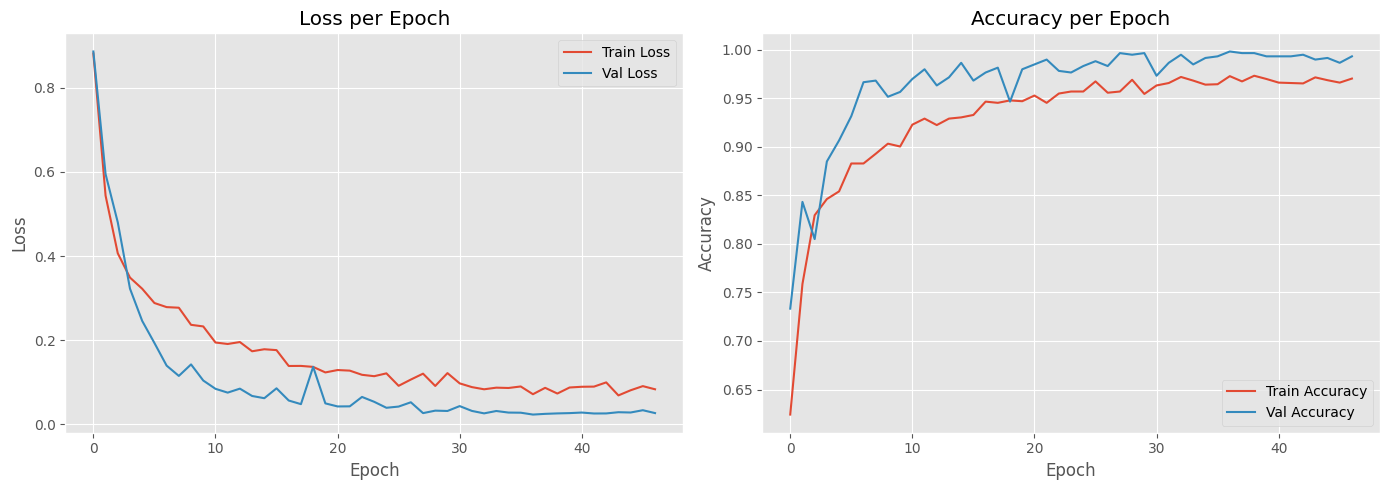


Neural Network Test Accuracy : 99.83%
Neural Network Test Loss     : 0.0234


In [46]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_run = len(history.history['loss'])
ep = np.arange(epochs_run)

# Loss
axes[0].plot(ep, history.history['loss'],     label='Train Loss')
axes[0].plot(ep, history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(ep, history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(ep, history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Final score
loss_nn, acc_nn = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nNeural Network Test Accuracy : {acc_nn:.2%}")
print(f"Neural Network Test Loss     : {loss_nn:.4f}")

# Inference

### Helper Functions

In [53]:
def hitung_bmi(berat_kg, tinggi_cm):
    tinggi_m = tinggi_cm / 100
    return round(berat_kg / (tinggi_m ** 2), 1)

def kategori_bmi(bmi):
    if bmi < 18.5: return "Kurus"
    if bmi < 25.0: return "Normal"
    if bmi < 30.0: return "Overweight"
    return "Obesitas"

def hitung_bmr(berat, tinggi, umur, gender='L'):
    # Mifflin-St Jeor
    if gender == 'L':
        return round(10*berat + 6.25*tinggi - 5*umur + 5)
    return round(10*berat + 6.25*tinggi - 5*umur - 161)

def berat_ideal(tinggi_cm, gender='L'):
    # Devine formula
    h_in = (tinggi_cm - 152.4) / 2.54
    if gender == 'L':
        return round(50 + 2.3 * max(0, h_in), 1)
    return round(45.5 + 2.3 * max(0, h_in), 1)

def kalori_bakar(met, berat_kg, durasi_menit):
    return round(met * berat_kg * (durasi_menit / 60), 1)

def estimasi_langkah(kalori, berat_kg):
    # 1 langkah ≈ 0.04 kal untuk 70 kg, proporsional berat
    kal_per_langkah = 0.04 * (berat_kg / 70)
    return int(kalori / kal_per_langkah)

def hari_sampai_ideal(berat_kg, target_kg, kal_per_hari=300):
    selisih_kg = max(0, berat_kg - target_kg)
    return int((selisih_kg * 7700) / kal_per_hari)

### Function rekomendasi Neural Network

In [51]:
# ── ai_recommender: sekarang pakai model NN ───────────────────────────────

def ai_recommender_nn(user_berat, user_tinggi, user_umur,
                      user_goal='Weight Loss', streak_week=0, gender='L'):
    """
    Input  : data user
    Output : dict berisi rekomendasi olahraga hari ini + kalkulasi kalori & langkah
    """
    # 1. Hitung BMI user
    bmi   = hitung_bmi(user_berat, user_tinggi)
    cat   = kategori_bmi(bmi)
    bmr   = hitung_bmr(user_berat, user_tinggi, user_umur, gender)
    ideal = berat_ideal(user_tinggi, gender)

    # 2. Encode goal & ambil category secara heuristik (Weight Loss → Walking/Running)
    goal_heuristic_map = {
        'Weight Loss':     'Walking',
        'Cardio & Agility':'Sports',
        'Cardio & Endurance': 'Running',
        'Health Maintenance': 'Walking',
        'Full Body Cardio':   'Water Activities',
        'Core & Stamina':     'Conditioning Exercise',
        'Muscle Gain':        'Resistance Training',
    }
    category_str = goal_heuristic_map.get(user_goal, 'Walking')

    # 3. Siapkan input fitur untuk model (harus sama persis dengan saat training)
    try:
        cat_enc  = le_category.transform([category_str])[0]
        goal_enc = le_goal.transform([user_goal])[0]
    except ValueError:
        # fallback jika label tidak dikenal
        cat_enc  = 0
        goal_enc = 0

    # MET awal estimasi dari BMI (akan di-refine oleh model)
    met_estimasi = max(1.0, 8.0 - (bmi - 18.5) * 0.2)

    fitur = np.array([[met_estimasi, cat_enc, goal_enc, bmi, streak_week]])
    fitur_scaled = scaler_nn.transform(fitur)

    # 4. Prediksi intensitas pakai NN
    pred_proba     = nn_model.predict(fitur_scaled, verbose=0)[0]
    pred_intensity = le_intensity.classes_[np.argmax(pred_proba)]
    confidence     = round(np.max(pred_proba) * 100, 1)

    # 5. Durasi progresif berdasarkan streak week
    durasi_base = {'Sedentary': 15, 'Light': 20, 'Moderate': 30, 'Vigorous': 40}
    durasi = min(durasi_base.get(pred_intensity, 30) + streak_week * 5, 60)

    # 6. Filter dataset & ambil rekomendasi
    kandidat = df[
        (df['Intensity_Level'] == pred_intensity) &
        (df['Goal_Tag'] == user_goal)
    ]
    if len(kandidat) == 0:
        kandidat = df[df['Intensity_Level'] == pred_intensity]

    rekomendasi = kandidat.sample(1, random_state=streak_week).iloc[0]

    # 7. Hitung kalori & langkah
    kal  = kalori_bakar(rekomendasi['MET_Value'], user_berat, durasi)
    step = estimasi_langkah(kal, user_berat)

    # 8. Hitung progress menuju ideal
    hari_target = hari_sampai_ideal(user_berat, ideal)

    return {
        "── INFO USER ──────────────────": "",
        "BMI"              : f"{bmi} ({cat})",
        "BMR"              : f"{bmr} kal/hari",
        "Berat Ideal"      : f"{ideal} kg",
        "Sisa BB Turun"    : f"{max(0, round(user_berat - ideal, 1))} kg",
        "Estimasi Hari"    : f"{hari_target} hari",
        "── REKOMENDASI HARI INI ───────": "",
        "Aktivitas"        : rekomendasi['Activity_Description'],
        "Kategori"         : rekomendasi['Category'],
        "Intensitas (NN)"  : f"{pred_intensity} (confidence: {confidence}%)",
        "Durasi"           : f"{durasi} menit",
        "MET"              : rekomendasi['MET_Value'],
        "Kalori Terbakar"  : f"{kal} kal",
        "Target Langkah"   : f"~{step:,} langkah" if step > 0 else "N/A",
        "Streak Week"      : f"Minggu ke-{streak_week}",
    }

Demo

In [50]:
skenario = [
    {"label": "Obesitas, Minggu Pertama",
     "args": dict(user_berat=90, user_tinggi=165, user_umur=28,
                  user_goal='Weight Loss', streak_week=0)},
    {"label": "Overweight, Sudah 4 Minggu",
     "args": dict(user_berat=75, user_tinggi=168, user_umur=32,
                  user_goal='Cardio & Endurance', streak_week=4)},
    {"label": "Normal, Mau Naik Otot",
     "args": dict(user_berat=65, user_tinggi=172, user_umur=25,
                  user_goal='Muscle Gain', streak_week=8)},
]

for s in skenario:
    print(f"\n{'='*55}")
    print(f"  {s['label']}")
    print('='*55)
    hasil = ai_recommender_nn(**s['args'])
    for k, v in hasil.items():
        if v == "":
            print(f"\n  {k}")
        else:
            print(f"  {k:<28} {v}")


  Obesitas, Minggu Pertama

  ── INFO USER ──────────────────
  BMI                          33.1 (Obesitas)
  BMR                          1796 kal/hari
  Berat Ideal                  61.4 kg
  Sisa BB Turun                28.6 kg
  Estimasi Hari                734 hari

  ── REKOMENDASI HARI INI ───────
  Aktivitas                    Recreational Dumbbell Shoulder Press
  Kategori                     Resistance Training
  Intensitas (NN)              Moderate (confidence: 99.80000305175781%)
  Durasi                       30 menit
  MET                          3.2
  Kalori Terbakar              144.0 kal
  Target Langkah               ~2,799 langkah
  Streak Week                  Minggu ke-0

  Overweight, Sudah 4 Minggu

  ── INFO USER ──────────────────
  BMI                          26.6 (Overweight)
  BMR                          1645 kal/hari
  Berat Ideal                  64.1 kg
  Sisa BB Turun                10.9 kg
  Estimasi Hari                279 hari

  ── REKOMENDASI 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



  ── INFO USER ──────────────────
  BMI                          22.0 (Normal)
  BMR                          1605 kal/hari
  Berat Ideal                  67.7 kg
  Sisa BB Turun                0 kg
  Estimasi Hari                0 hari

  ── REKOMENDASI HARI INI ───────
  Aktivitas                    Competitive high-intensity Bench Press
  Kategori                     Resistance Training
  Intensitas (NN)              Vigorous (confidence: 99.80000305175781%)
  Durasi                       60 menit
  MET                          7.9
  Kalori Terbakar              513.5 kal
  Target Langkah               ~13,825 langkah
  Streak Week                  Minggu ke-8
